<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
 7   Year                                     740 non-null    int32         
 8   Month                                    740 non-null    int32         
dtypes: datetime64[ns](1), float64(3), int32(2), objec

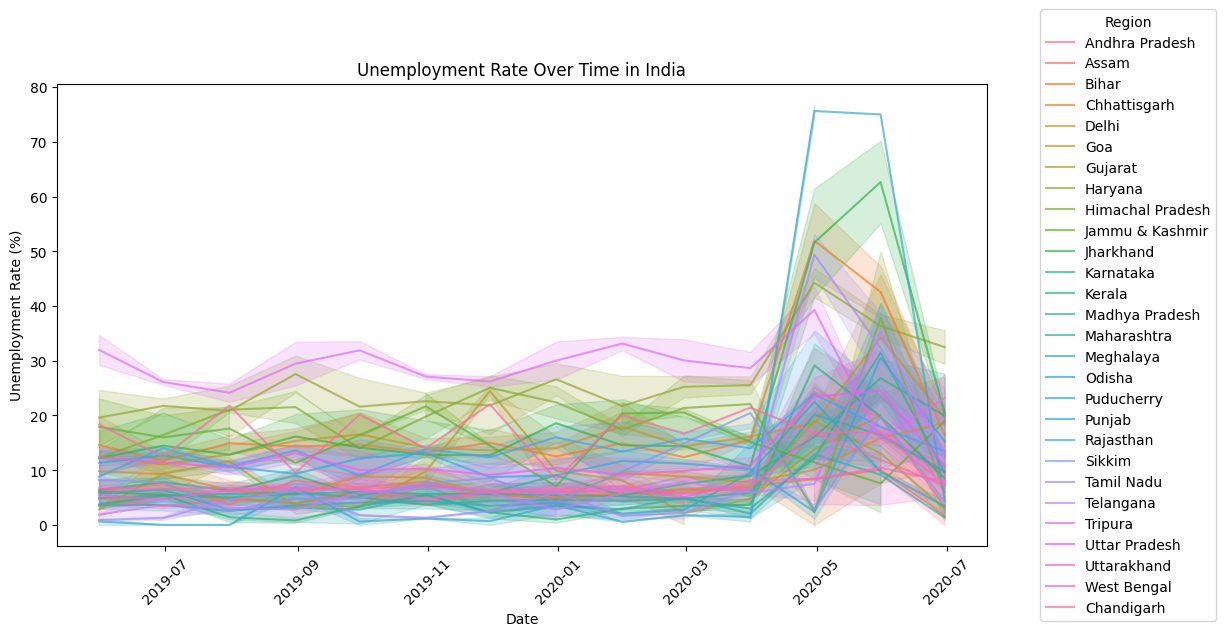

C:\Users\cm\AppData\Local\Temp\ipykernel_2168\2513173022.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_unemployment.values, y=avg_unemployment.index, palette="viridis")


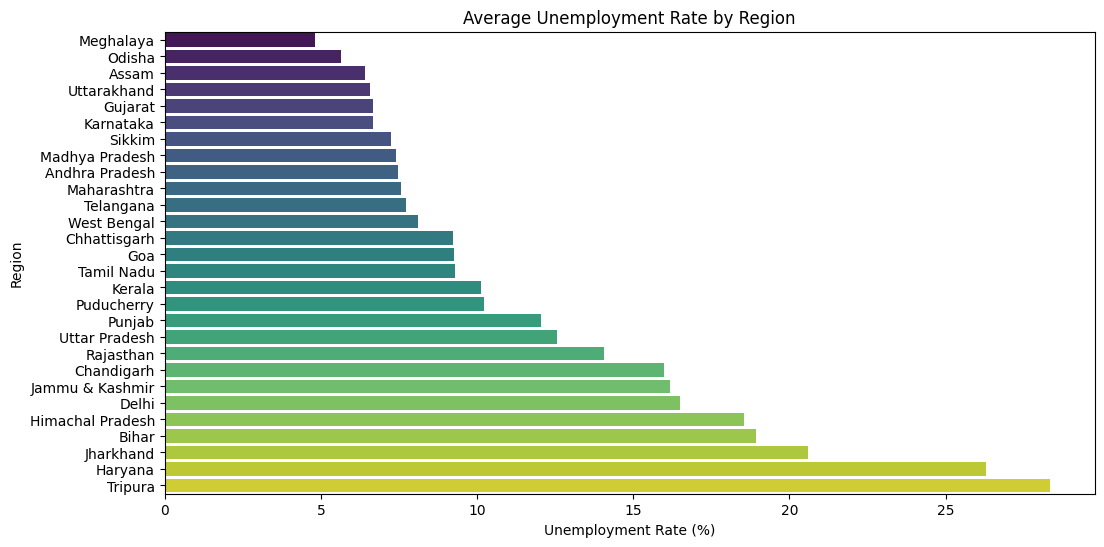

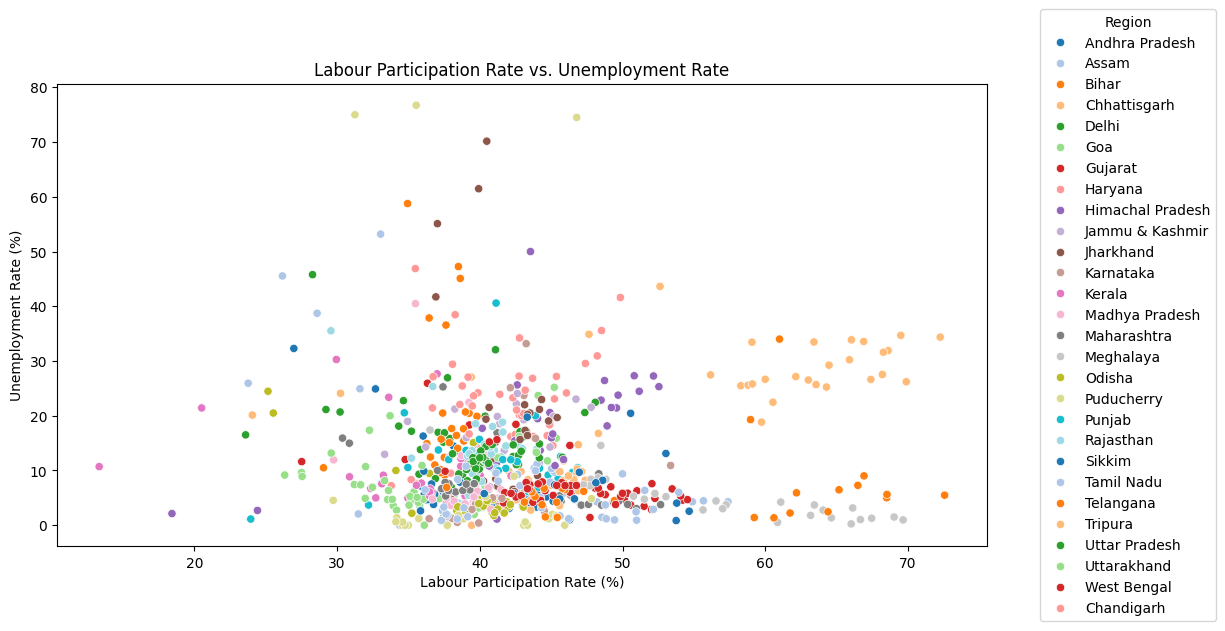

C:\Users\cm\AppData\Local\Temp\ipykernel_2168\2513173022.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Estimated Unemployment Rate (%)", palette="Set2")


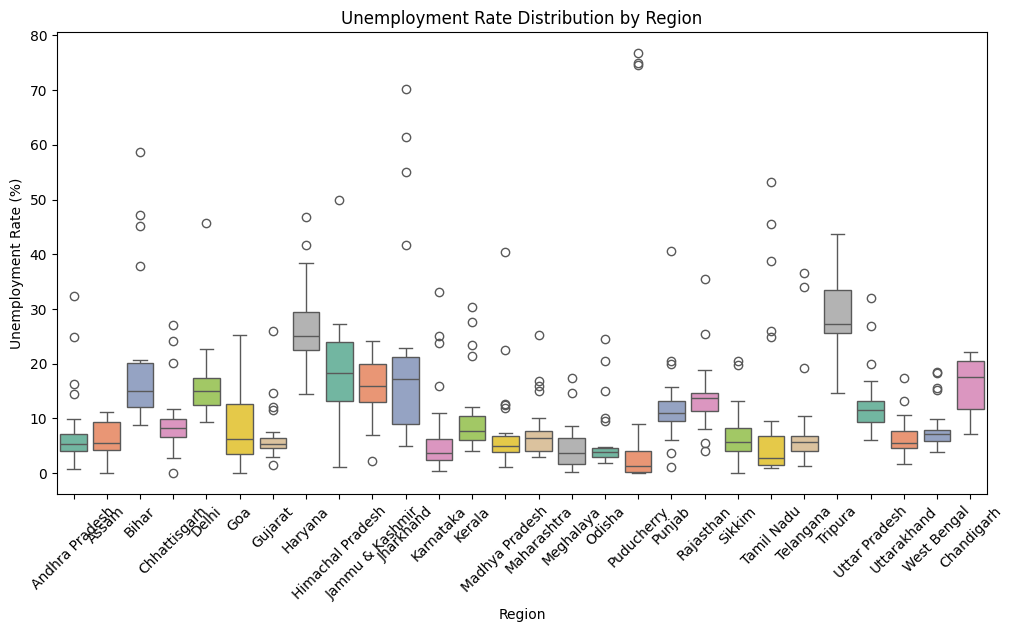

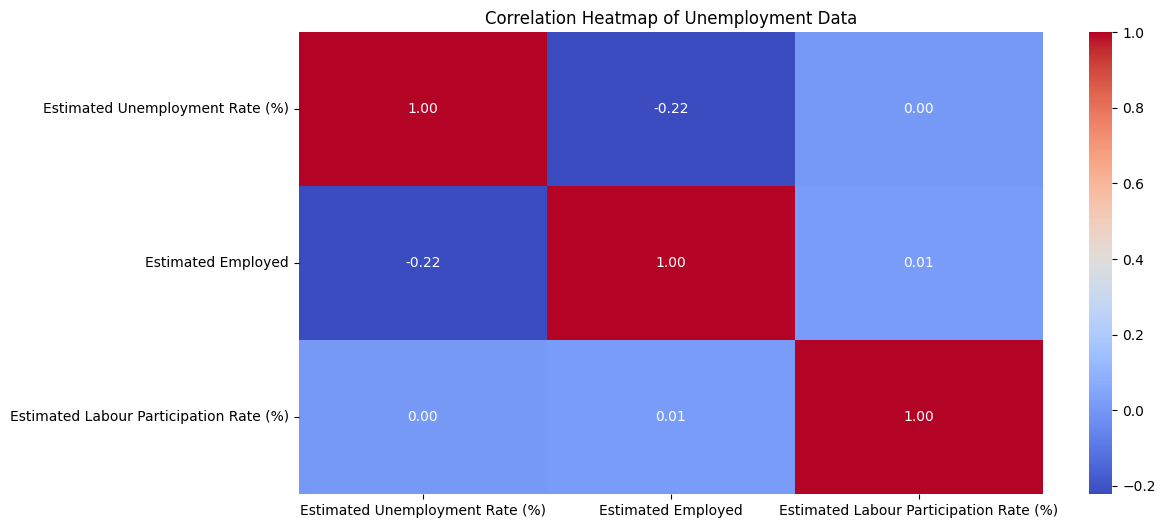

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = r"D:\data science projects\10unemployment rate in india\Unemployment in India.csv"
df = pd.read_csv(file_path)

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Remove spaces from 'Date' and convert to datetime
df['Date'] = df['Date'].str.strip()  
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y", dayfirst=True)

# Drop missing values
df.dropna(inplace=True)

# Extract Year and Month for better analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Display basic dataset info
print(df.info())
print(df.describe())

### 1) Time Series Plot: Unemployment Rate Over Time ###
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Date", y="Estimated Unemployment Rate (%)", alpha=0.7, hue="Region")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.title("Unemployment Rate Over Time in India")
plt.xticks(rotation=45)

# Shift the legend to the right
plt.legend(title="Region", bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

### 2) Regional Unemployment Rate Comparison ###
# Plot the average unemployment rate by region
plt.figure(figsize=(12, 6))
avg_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()
sns.barplot(x=avg_unemployment.values, y=avg_unemployment.index, palette="viridis")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Region")
plt.title("Average Unemployment Rate by Region")
plt.show()

### 3) Labour Participation Rate vs. Unemployment Rate ###
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="Estimated Labour Participation Rate (%)", y="Estimated Unemployment Rate (%)", hue="Region", palette="tab20")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.title("Labour Participation Rate vs. Unemployment Rate")
plt.legend(title="Region", bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

### 4) Distribution of Unemployment Rates Across Regions ###
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Region", y="Estimated Unemployment Rate (%)", palette="Set2")
plt.title("Unemployment Rate Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

### 5) Correlation Heatmap Between Key Variables ###
# Select only numeric columns for correlation
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix using only numeric columns
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Unemployment Data")
plt.show()
